In [1]:
 #Basic Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Model & Evaluation
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, accuracy_score

# Matrix Factorization
from scipy.sparse.linalg import svds

import warnings
warnings.filterwarnings("ignore")

ModuleNotFoundError: No module named 'numpy'

In [3]:
#pip install numpy pandas matplotlib seaborn scikit-learn scipy

In [4]:
pip install numpy pandas matplotlib seaborn scikit-learn scipy

  Using cached numpy-2.2.6-cp310-cp310-win_amd64.whl (12.9 MB)
  Using cached pandas-2.3.3-cp310-cp310-win_amd64.whl (11.3 MB)
     ---------------------------------------- 0.0/8.2 MB ? eta -:--:--
     ---------------------------------------- 0.0/8.2 MB ? eta -:--:--
     ---------------------------------------- 0.0/8.2 MB 487.6 kB/s eta 0:00:17
      --------------------------------------- 0.1/8.2 MB 1.1 MB/s eta 0:00:08
      --------------------------------------- 0.2/8.2 MB 1.2 MB/s eta 0:00:07
     - -------------------------------------- 0.3/8.2 MB 1.4 MB/s eta 0:00:06
     - -------------------------------------- 0.4/8.2 MB 1.6 MB/s eta 0:00:05
     -- ------------------------------------- 0.5/8.2 MB 1.6 MB/s eta 0:00:05
     -- ------------------------------------- 0.5/8.2 MB 1.7 MB/s eta 0:00:05
     -- ------------------------------------- 0.6/8.2 MB 1.6 MB/s eta 0:00:05
     --- ------------------------------------ 0.7/8.2 MB 1.7 MB/s eta 0:00:05
     --- ------------------

ERROR: Could not install packages due to an OSError: [WinError 32] The process cannot access the file because it is being used by another process: 'c:\\Users\\ksano\\OneDrive\\Documents\\.venv\\Lib\\site-packages\\sklearn\\_build_utils\\tempita.py'
Check the permissions.


[notice] A new release of pip is available: 23.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


  Using cached matplotlib-3.10.9-cp310-cp310-win_amd64.whl (8.2 MB)
  Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
  Using cached scikit_learn-1.7.2-cp310-cp310-win_amd64.whl (8.9 MB)
  Using cached contourpy-1.3.2-cp310-cp310-win_amd64.whl (221 kB)
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
#Basic Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Model & Evaluation
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, accuracy_score

# Matrix Factorization
from scipy.sparse.linalg import svds

import warnings
warnings.filterwarnings("ignore")

In [10]:
users = pd.read_csv(r"C:\Users\ksano\Downloads\Users.csv", encoding='latin-1')
books = pd.read_csv(r"C:\Users\ksano\Downloads\Books.csv", encoding='latin-1')
ratings = pd.read_csv(r"C:\Users\ksano\Downloads\Ratings.csv", encoding='latin-1')

In [11]:
print("Books Shape:", books.shape)
print("Users Shape:", users.shape)
print("Ratings Shape:", ratings.shape)

Books Shape: (271360, 8)
Users Shape: (278858, 3)
Ratings Shape: (1149780, 3)


In [12]:
books.head()

,ISBN,Book-Title,Book-Author,Year-Of-Publication,Publisher,Image-URL-S,Image-URL-M,Image-URL-L
0,0195153448,Classical Mythology,Mark P. O. Morford,2002,Oxford University Press,http://images.amazon.com/images/P/0195153448.0...,http://images.amazon.com/images/P/0195153448.0...,http://images.amazon.com/images/P/0195153448.0...
1,0002005018,Clara Callan,Richard Bruce Wright,2001,HarperFlamingo Canada,http://images.amazon.com/images/P/0002005018.0...,http://images.amazon.com/images/P/0002005018.0...,http://images.amazon.com/images/P/0002005018.0...
2,0060973129,Decision in Normandy,Carlo D'Este,1991,HarperPerennial,http://images.amazon.com/images/P/0060973129.0...,http://images.amazon.com/images/P/0060973129.0...,http://images.amazon.com/images/P/0060973129.0...
3,0374157065,Flu: The Story of the Great Influenza Pandemic...,Gina Bari Kolata,1999,Farrar Straus Giroux,http://images.amazon.com/images/P/0374157065.0...,http://images.amazon.com/images/P/0374157065.0...,http://images.amazon.com/images/P/0374157065.0...
4,0393045218,The Mummies of Urumchi,E. J. W. Barber,1999,W. W. Norton &amp; Company,http://images.amazon.com/images/P/0393045218.0...,http://images.amazon.com/images/P/0393045218.0...,http://images.amazon.com/images/P/0393045218.0...


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 271360 entries, 0 to 271359
Data columns (total 8 columns):
 #   Column               Non-Null Count   Dtype 
---  ------               --------------   ----- 
 0   ISBN                 271360 non-null  object
 1   Book-Title           271360 non-null  object
 2   Book-Author          271358 non-null  object
 3   Year-Of-Publication  271360 non-null  object
 4   Publisher            271358 non-null  object
 5   Image-URL-S          271360 non-null  object
 6   Image-URL-M          271360 non-null  object
 7   Image-URL-L          271357 non-null  object
dtypes: object(8)
memory usage: 16.6+ MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 278858 entries, 0 to 278857
Data columns (total 3 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   User-ID   278858 non-null  int64  
 1   Location  278858 non-null  object 
 2   Age       168096 non-null  float64
dtypes: float64(1), int64(1), object(1)

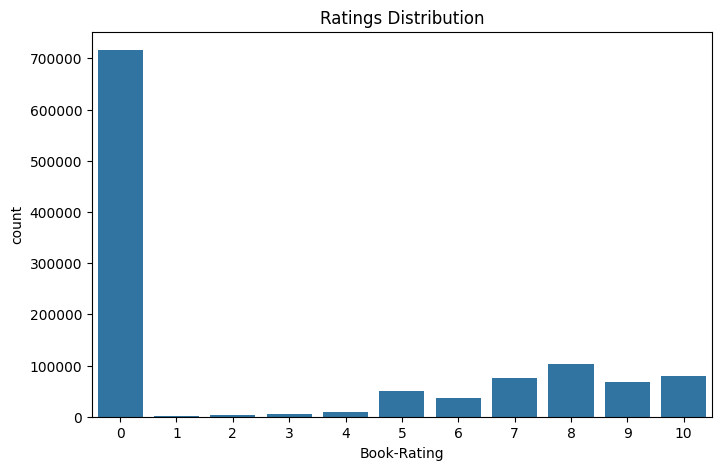

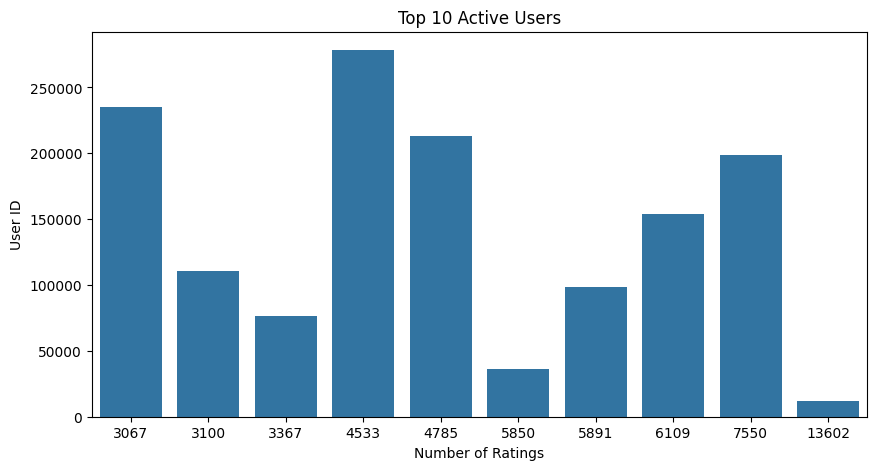

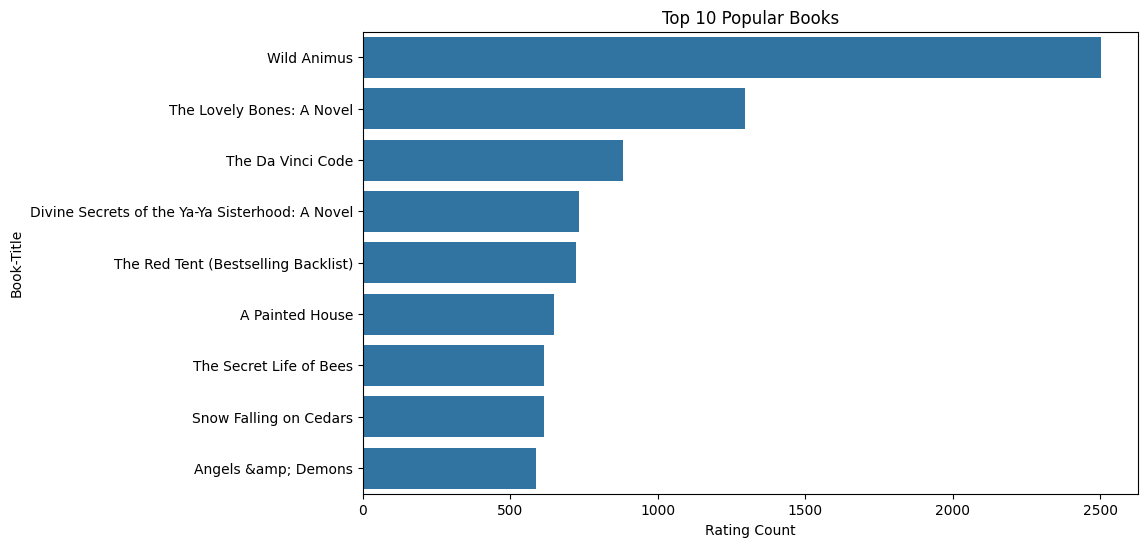

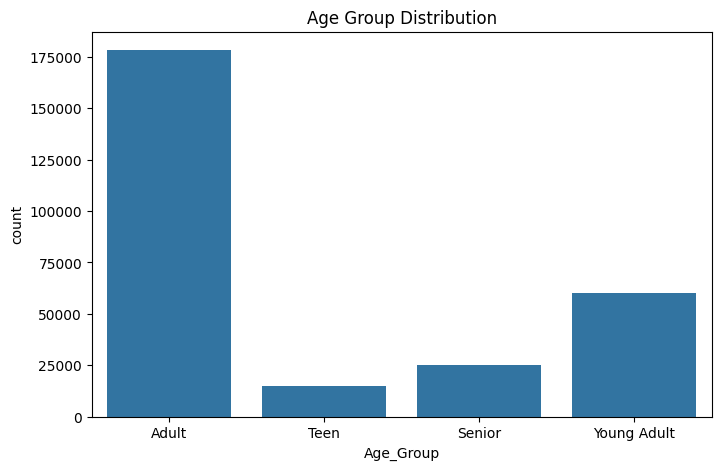

Merged Data Shape: (383842, 13)
Filtered Data: (18288, 13)


In [14]:
users.head()
ratings.head()
books.info()
users.info()
ratings.info()
books.describe()
users.describe()
ratings.describe()
print("Books Missing Values:\n", books.isnull().sum())
print("\nUsers Missing Values:\n", users.isnull().sum())
print("\nRatings Missing Values:\n", ratings.isnull().sum())
#rating distribution
plt.figure(figsize=(8,5))
sns.countplot(x='Book-Rating', data=ratings)
plt.title("Ratings Distribution")
plt.show()
#active users
active_users = ratings['User-ID'].value_counts().head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=active_users.values, y=active_users.index)
plt.title("Top 10 Active Users")
plt.xlabel("Number of Ratings")
plt.ylabel("User ID")
plt.show()
#popular books
popular_books = ratings['ISBN'].value_counts().head(10).reset_index()
popular_books.columns = ['ISBN','Rating Count']

popular_books = popular_books.merge(books[['ISBN','Book-Title']], on='ISBN')

plt.figure(figsize=(10,6))
sns.barplot(x='Rating Count', y='Book-Title', data=popular_books)
plt.title("Top 10 Popular Books")
plt.show()
# Clean unrealistic ages
users['Age'] = users['Age'].apply(lambda x: x if 5 <= x <= 90 else np.nan)

# Fill missing with median
users['Age'].fillna(users['Age'].median(), inplace=True)

# Create Age Groups
def age_group(age):
    if age <= 18:
        return "Teen"
    elif age <= 30:
        return "Young Adult"
    elif age <= 50:
        return "Adult"
    else:
        return "Senior"

users['Age_Group'] = users['Age'].apply(age_group)

# Visualize
plt.figure(figsize=(8,5))
sns.countplot(x='Age_Group', data=users)
plt.title("Age Group Distribution")
plt.show()
#merge all datasets
data = ratings.merge(books, on='ISBN')
data = data.merge(users, on='User-ID')

# Remove implicit ratings
data = data[data['Book-Rating'] > 0]

print("Merged Data Shape:", data.shape)
#keep only active users
active_users = data['User-ID'].value_counts()
active_users = active_users[active_users > 50].index

popular_books = data['Book-Title'].value_counts()
popular_books = popular_books[popular_books > 50].index

data = data[data['User-ID'].isin(active_users)]
data = data[data['Book-Title'].isin(popular_books)]

print("Filtered Data:", data.shape)
train, test = train_test_split(data, test_size=0.2, random_state=42)
mean_rating = train['Book-Rating'].mean()
pop_predictions = np.full(len(test), mean_rating)


In [15]:
pivot = train.pivot_table(index='User-ID',
                          columns='Book-Title',
                          values='Book-Rating').fillna(0)

user_similarity = cosine_similarity(pivot)
user_similarity_df = pd.DataFrame(user_similarity,
                                  index=pivot.index,
                                  columns=pivot.index)

def predict_user_based(user_id):
    similar_users = user_similarity_df[user_id]
    weighted_ratings = np.dot(similar_users, pivot)
    norm = np.sum(np.abs(similar_users))
    return weighted_ratings / norm

In [16]:
actual_user = []
pred_user = []

for _, row in test.iterrows():
    user = row['User-ID']
    book = row['Book-Title']

    if user in pivot.index and book in pivot.columns:
        prediction = predict_user_based(user)[pivot.columns.get_loc(book)]
        actual_user.append(row['Book-Rating'])
        pred_user.append(prediction)

In [17]:
matrix= pivot.values
U, sigma, Vt = svds(matrix, k=50)
sigma = np.diag(sigma)

predicted_ratings = np.dot(np.dot(U, sigma), Vt)

In [18]:
actual_svd = []
pred_svd = []

for _, row in test.iterrows():
    user = row['User-ID']
    book = row['Book-Title']

    if user in pivot.index and book in pivot.columns:
        user_idx = list(pivot.index).index(user)
        book_idx = list(pivot.columns).index(book)

        prediction = predicted_ratings[user_idx, book_idx]
        actual_svd.append(row['Book-Rating'])
        pred_svd.append(prediction)


In [19]:
def evaluate_model(actual, predicted, threshold=7):

    actual = np.array(actual)
    predicted = np.array(predicted)

    rmse = np.sqrt(mean_squared_error(actual, predicted))
    mae = mean_absolute_error(actual, predicted)

    actual_binary = (actual >= threshold).astype(int)
    pred_binary = (predicted >= threshold).astype(int)

    accuracy = accuracy_score(actual_binary, pred_binary)

    return rmse, mae, accuracy

In [20]:
rmse_pop, mae_pop, acc_pop = evaluate_model(test['Book-Rating'], pop_predictions)
rmse_user, mae_user, acc_user = evaluate_model(actual_user, pred_user)
rmse_svd, mae_svd, acc_svd = evaluate_model(actual_svd, pred_svd)

results = pd.DataFrame({
    'Model': ['Popularity','User-Based CF','SVD'],
    'RMSE': [rmse_pop, rmse_user, rmse_svd],
    'MAE': [mae_pop, mae_user, mae_svd],
    'Accuracy': [acc_pop, acc_user, acc_svd]
})

results

,Model,RMSE,MAE,Accuracy
0,Popularity,1.760160,1.343483,0.826955
1,User-Based CF,7.782044,7.582291,0.173388
2,SVD,7.581612,7.295882,0.180796


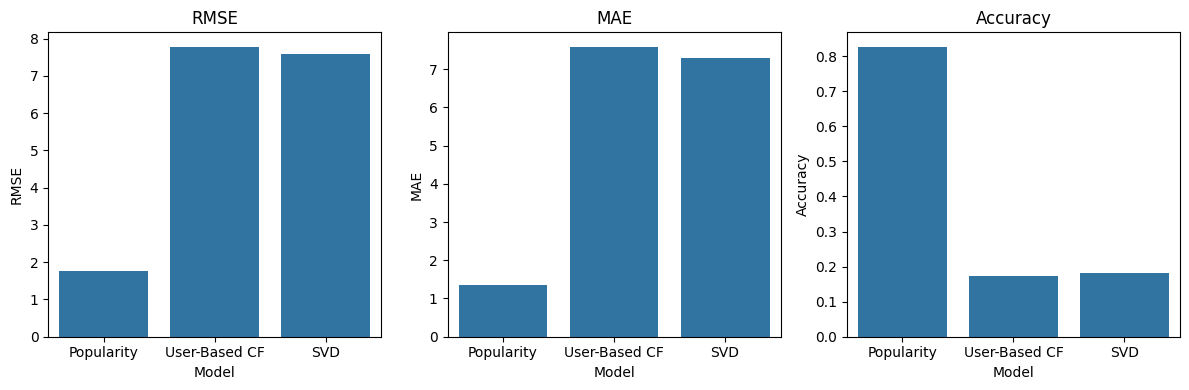

In [21]:
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
sns.barplot(x='Model', y='RMSE', data=results)
plt.title("RMSE")

plt.subplot(1,3,2)
sns.barplot(x='Model', y='MAE', data=results)
plt.title("MAE")

plt.subplot(1,3,3)
sns.barplot(x='Model', y='Accuracy', data=results)
plt.title("Accuracy")

plt.tight_layout()
plt.show()

In [22]:
import pickle

pickle.dump(pivot, open("pivot.pkl", "wb"))
pickle.dump(predicted_ratings, open("svd_predictions.pkl", "wb"))
pickle.dump(list(pivot.columns), open("book_names.pkl", "wb"))

print("Files saved successfully!")

Files saved successfully!
